# Race Classifier Training (Improved, 3-Stage Fine-Tuning)

Race classification model using a ResNet50 backbone and 3-stage fine-tuning.

- **Label:** `race_id` (`0=White, 1=Black, 2=Asian, 3=Indian, 4=Others`)
- **Loss:** Sparse categorical cross-entropy
- **Framework:** TensorFlow / Keras


In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATA_DIR = Path("/content/data")
    CHECKPOINT_DIR = Path("/content/checkpoints/race_classifier")
else:
    NOTEBOOK_DIR = Path(".").resolve()
    PROJECT_ROOT = NOTEBOOK_DIR.parent
    DATA_DIR = PROJECT_ROOT / "data"
    CHECKPOINT_DIR = PROJECT_ROOT / "models" / "race_classifier"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

IMAGES_DIR = DATA_DIR / "utk_face"
TRAIN_CSV = DATA_DIR / "splits" / "train_gender.csv"
VAL_CSV = DATA_DIR / "splits" / "val_gender.csv"
TEST_CSV = DATA_DIR / "splits" / "test.csv"

BEST_MODEL = CHECKPOINT_DIR / "best_race_model.keras"

print(f"Running in Colab: {IN_COLAB}")
print(f"Data dir        : {DATA_DIR}")
print(f"Images dir      : {IMAGES_DIR}")
print(f"Checkpoint dir  : {CHECKPOINT_DIR}")


Running in Colab: True
Data dir        : /content/data
Images dir      : /content/data/utk_face
Checkpoint dir  : /content/checkpoints/race_classifier


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    f1_score,
)
from sklearn.preprocessing import label_binarize

print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {tf.config.list_physical_devices('GPU')}")

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_STAGE1 = 20
EPOCHS_STAGE2 = 15
EPOCHS_STAGE3 = 15
LR_STAGE1 = 1e-3
LR_STAGE2 = 1e-5
LR_STAGE3 = 5e-6
DROPOUT_RATE = 0.3
DENSE_UNITS = 256
NUM_CLASSES = 5
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)


TensorFlow version : 2.19.0
GPUs available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
RACE_LABEL_NAMES = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Others",
}

def load_race_dataframe(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["filepath"] = df["filename"].apply(lambda fname: str(IMAGES_DIR / fname))
    df["label"] = df["race_id"].astype(int)
    df["race_name"] = df["label"].map(RACE_LABEL_NAMES)
    return df[["filepath", "label", "race_name"]]

train_df = load_race_dataframe(TRAIN_CSV)
val_df = load_race_dataframe(VAL_CSV)
test_df = load_race_dataframe(TEST_CSV)

print(f"Train samples: {len(train_df)}")
print(f"Val samples  : {len(val_df)}")
print(f"Test samples : {len(test_df)}")

print("\nTrain label distribution:")
print(train_df["label"].value_counts().sort_index().rename(index=RACE_LABEL_NAMES))

label_counts = train_df["label"].value_counts().sort_index()
class_weights = {
    int(k): float(len(train_df) / (NUM_CLASSES * v))
    for k, v in label_counts.items()
}
norm = np.mean(list(class_weights.values()))
class_weights = {k: v / norm for k, v in class_weights.items()}

train_df = train_df.copy()
train_df["sample_weight"] = train_df["label"].map(class_weights).astype(np.float32)
val_df = val_df.copy()
val_df["sample_weight"] = 1.0
test_df = test_df.copy()
test_df["sample_weight"] = 1.0

print("\nClass weights:")
for k in sorted(class_weights):
    print(f"  {RACE_LABEL_NAMES[k]}: {class_weights[k]:.4f}")


Train samples: 14104
Val samples  : 6045
Test samples : 3556

Train label distribution:
label
White     6021
Black     2652
Asian     2054
Indian    2357
Others    1020
Name: count, dtype: int64

Class weights:
  White: 0.3411
  Black: 0.7744
  Asian: 0.9998
  Indian: 0.8713
  Others: 2.0134


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

def parse_image(filepath: tf.Tensor, label: tf.Tensor, sw: tf.Tensor):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = preprocess_input(image)
    return image, label, sw

def augment(image: tf.Tensor, label: tf.Tensor, sw: tf.Tensor):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    return image, label, sw

def make_dataset(df: pd.DataFrame, training: bool = False, use_weights: bool = False) -> tf.data.Dataset:
    filepaths = df["filepath"].to_numpy()
    labels = df["label"].to_numpy(dtype=np.int32)
    sample_weights = df["sample_weight"].to_numpy(dtype=np.float32)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels, sample_weights))

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    if use_weights:
        ds = ds.map(lambda x, y, w: (x, y, w), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda x, y, w: (x, y), num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True, use_weights=True)
val_ds = make_dataset(val_df, training=False, use_weights=False)
test_ds = make_dataset(test_df, training=False, use_weights=False)

print("Datasets built successfully.")


Datasets built successfully.


In [5]:
def build_model(learning_rate: float, model_name: str) -> keras.Model:
    backbone = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMAGE_SIZE, 3),
        name="resnet50",
    )
    backbone.trainable = False

    inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name="image_input")
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(DENSE_UNITS, activation="relu", name="fc1")(x)
    x = layers.Dropout(DROPOUT_RATE, name="dropout")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="race_output")(x)

    model = keras.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )
    return model

def freeze_backbone_except(backbone: keras.Model, trainable_prefixes: tuple[str, ...]) -> None:
    backbone.trainable = True
    for layer in backbone.layers:
        layer.trainable = any(layer.name.startswith(prefix) for prefix in trainable_prefixes)
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

def make_callbacks(stage_name: str, patience: int = 5):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(BEST_MODEL),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=max(2, patience // 2),
            min_lr=1e-7,
            verbose=1,
        ),
    ]


In [6]:
# Stage 1: train head with frozen backbone
if not BEST_MODEL.exists():
    model = build_model(learning_rate=LR_STAGE1, model_name="race_classifier")
else:
    model = keras.models.load_model(str(BEST_MODEL))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR_STAGE1),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=make_callbacks("stage1"),
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4531 - loss: 1.0619
Epoch 1: val_accuracy improved from None to 0.48453, saving model to /content/checkpoints/race_classifier/best_race_model.keras

Epoch 1: finished saving model to /content/checkpoints/race_classifier/best_race_model.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 88s 164ms/step - accuracy: 0.5161 - loss: 0.9456 - val_accuracy: 0.4845 - val_loss: 1.2806 - learning_rate: 0.0010
Epoch 2/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5817 - loss: 0.8332
Epoch 2: val_accuracy improved from 0.48453 to 0.61274, saving model to /content/checkpoints/race_classifier/best_race_model.keras

Epoch 2: finished saving model to /content/checkpoints/race_classifier/best_race_model.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 60s 136ms/step - accuracy: 0.5877 - loss: 0.8219 - val_accuracy: 0.6127 - val_loss: 1.0409 - learning_rate: 0.0010
Epoch 3/20
441/441 ━━━━━━━━━━━━━━━━━━━━

In [7]:
# Stage 2: fine-tune conv5
model = keras.models.load_model(str(BEST_MODEL))
backbone = model.get_layer("resnet50")
freeze_backbone_except(backbone, trainable_prefixes=("conv5",))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_STAGE2),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=make_callbacks("stage2"),
)


Epoch 1/15
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7120 - loss: 0.5799
Epoch 1: val_accuracy improved from None to 0.67345, saving model to /content/checkpoints/race_classifier/best_race_model.keras

Epoch 1: finished saving model to /content/checkpoints/race_classifier/best_race_model.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 103s 199ms/step - accuracy: 0.7126 - loss: 0.5755 - val_accuracy: 0.6734 - val_loss: 0.8995 - learning_rate: 1.0000e-05
Epoch 2/15
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7491 - loss: 0.5019
Epoch 2: val_accuracy did not improve from 0.67345
441/441 ━━━━━━━━━━━━━━━━━━━━ 78s 177ms/step - accuracy: 0.7444 - loss: 0.5063 - val_accuracy: 0.6548 - val_loss: 0.9438 - learning_rate: 1.0000e-05
Epoch 3/15
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.7664 - loss: 0.4593
Epoch 3: val_accuracy improved from 0.67345 to 0.70587, saving model to /content/checkpoints/race_classifier/best_race_model.keras

Epoch 3: finished saving model to 

In [8]:
# Stage 3: fine-tune conv4 + conv5
model = keras.models.load_model(str(BEST_MODEL))
backbone = model.get_layer("resnet50")
freeze_backbone_except(backbone, trainable_prefixes=("conv4", "conv5"))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_STAGE3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

history_stage3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE3,
    callbacks=make_callbacks("stage3"),
)

print(f"Training complete. Best model saved to: {BEST_MODEL}")


Epoch 1/15
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.8756 - loss: 0.2399
Epoch 1: val_accuracy improved from None to 0.69595, saving model to /content/checkpoints/race_classifier/best_race_model.keras

Epoch 1: finished saving model to /content/checkpoints/race_classifier/best_race_model.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 138s 265ms/step - accuracy: 0.8738 - loss: 0.2431 - val_accuracy: 0.6959 - val_loss: 1.0216 - learning_rate: 5.0000e-06
Epoch 2/15
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.8862 - loss: 0.2138
Epoch 2: val_accuracy improved from 0.69595 to 0.74260, saving model to /content/checkpoints/race_classifier/best_race_model.keras

Epoch 2: finished saving model to /content/checkpoints/race_classifier/best_race_model.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 111s 251ms/step - accuracy: 0.8850 - loss: 0.2149 - val_accuracy: 0.7426 - val_loss: 0.8917 - learning_rate: 5.0000e-06
Epoch 3/15
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.8974 - loss

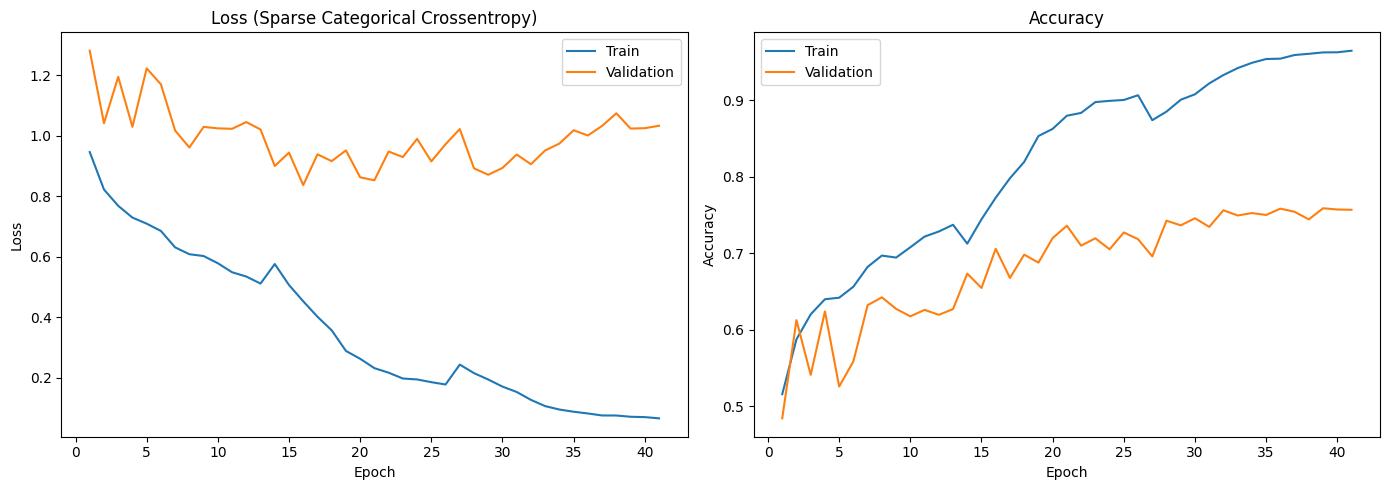

In [9]:
def _concat_metric(histories, key: str):
    values = []
    for h in histories:
        values.extend(h.history.get(key, []))
    return values

all_histories = [history_stage1, history_stage2, history_stage3]
train_loss = _concat_metric(all_histories, "loss")
val_loss = _concat_metric(all_histories, "val_loss")
train_acc = _concat_metric(all_histories, "accuracy")
val_acc = _concat_metric(all_histories, "val_accuracy")

epoch_axis = np.arange(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epoch_axis, train_loss, label="Train")
axes[0].plot(epoch_axis, val_loss, label="Validation")
axes[0].set_title("Loss (Sparse Categorical Crossentropy)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epoch_axis, train_acc, label="Train")
axes[1].plot(epoch_axis, val_acc, label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


Loaded best model from: /content/checkpoints/race_classifier/best_race_model.keras

Test Accuracy : 0.7497
Test Macro-F1 : 0.6760
Test AUC (OvR): 0.9174

Classification Report:
              precision    recall  f1-score   support

       White       0.86      0.80      0.83      1455
       Black       0.86      0.74      0.80       684
       Asian       0.66      0.87      0.75       530
      Indian       0.68      0.73      0.70       630
      Others       0.32      0.29      0.31       257

    accuracy                           0.75      3556
   macro avg       0.67      0.69      0.68      3556
weighted avg       0.76      0.75      0.75      3556



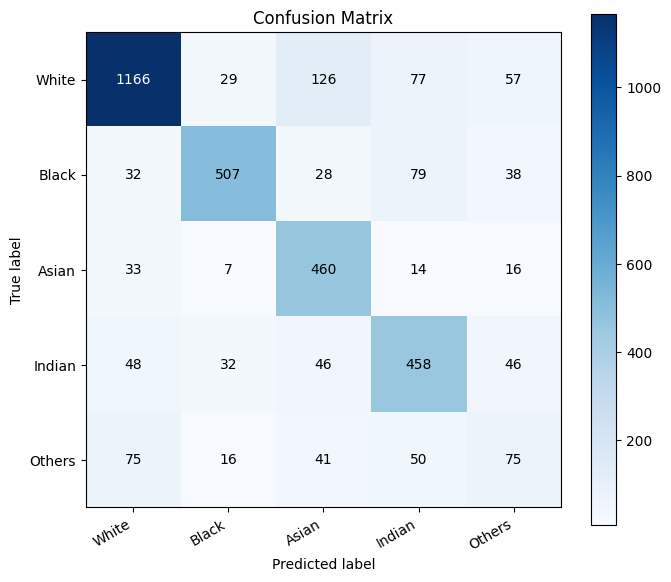

In [10]:
import itertools

def plot_confusion_matrix(cm: np.ndarray, class_names: list[str]) -> None:
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=30, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
        )
    plt.tight_layout()
    plt.show()

best_model = keras.models.load_model(str(BEST_MODEL))
print(f"Loaded best model from: {BEST_MODEL}")

y_true_list: list[int] = []
y_prob_list: list[np.ndarray] = []

for images, labels in test_ds:
    probs = best_model(images, training=False).numpy()
    y_true_list.extend(labels.numpy().tolist())
    y_prob_list.extend(probs.tolist())

y_true = np.array(y_true_list, dtype=np.int32)
y_probs = np.array(y_prob_list, dtype=np.float32)
y_pred = np.argmax(y_probs, axis=1)

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
auc_ovr = roc_auc_score(y_true_bin, y_probs, multi_class="ovr", average="macro")

print(f"\nTest Accuracy : {acc:.4f}")
print(f"Test Macro-F1 : {macro_f1:.4f}")
print(f"Test AUC (OvR): {auc_ovr:.4f}")
print()
print("Classification Report:")
target_names = [RACE_LABEL_NAMES[i] for i in range(NUM_CLASSES)]
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plot_confusion_matrix(cm, class_names=target_names)


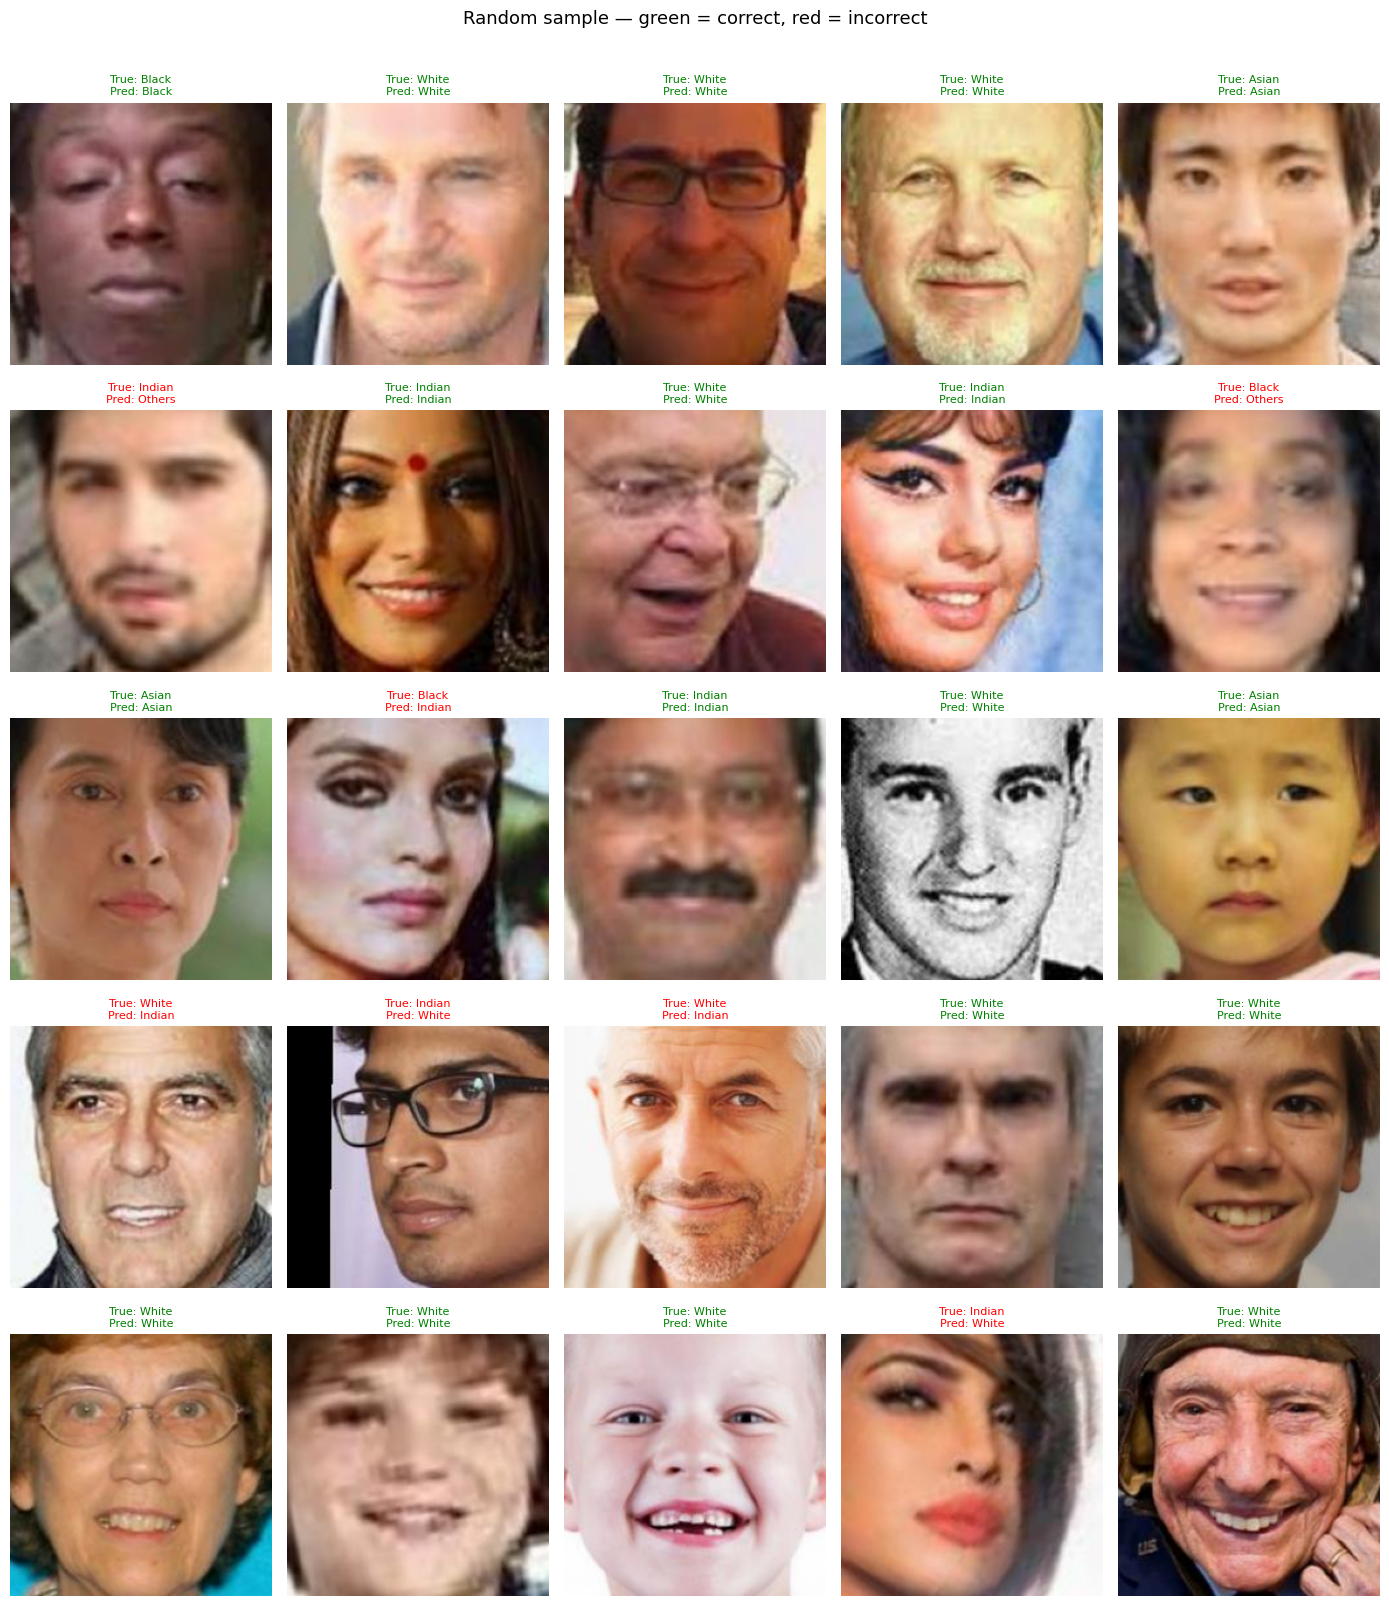

Total incorrect predictions: 890 / 3556


In [ ]:
def load_display_image(filepath: str) -> np.ndarray:
    img = PILImage.open(filepath).convert("RGB").resize(IMAGE_SIZE)
    return np.array(img)

def render_grid(
    filepaths: list[str],
    true_labels: list[int],
    pred_labels: list[int],
    title: str,
    ncols: int = 5,
) -> None:
    n = len(filepaths)
    if n == 0:
        print(f"{title}: no images to display.")
        return

    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.8, nrows * 3.2))
    axes = np.array(axes).reshape(-1)

    for idx in range(len(axes)):
        ax = axes[idx]
        if idx >= n:
            ax.axis("off")
            continue
        img = load_display_image(filepaths[idx])
        true = RACE_LABEL_NAMES[true_labels[idx]]
        pred = RACE_LABEL_NAMES[pred_labels[idx]]
        color = "green" if true_labels[idx] == pred_labels[idx] else "red"
        ax.imshow(img)
        ax.set_title(f"True: {true}\nPred: {pred}", fontsize=8, color=color)
        ax.axis("off")

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

all_filepaths = test_df["filepath"].tolist()
all_true = y_true.tolist()
all_pred = y_pred.tolist()

rng = np.random.default_rng(seed=SEED)
sample_n = min(25, len(all_filepaths))
sample_idx = rng.choice(len(all_filepaths), size=sample_n, replace=False).tolist()

render_grid(
    filepaths=[all_filepaths[i] for i in sample_idx],
    true_labels=[all_true[i] for i in sample_idx],
    pred_labels=[all_pred[i] for i in sample_idx],
    title="Random sample — green = correct, red = incorrect",
    ncols=5,
)

wrong_idx = [i for i, (t, p) in enumerate(zip(all_true, all_pred)) if t != p]
print(f"Total incorrect predictions: {len(wrong_idx)} / {len(all_true)}")

render_grid(
    filepaths=[all_filepaths[i] for i in wrong_idx],
    true_labels=[all_true[i] for i in wrong_idx],
    pred_labels=[all_pred[i] for i in wrong_idx],
    title="All incorrect predictions (True → Predicted)",
    ncols=8,
)
